<h1 style="color:red">🎯 Objectif du jour</h1>
<h2>Maîtriser SQL depuis Python pour interroger, manipuler et analyser des données dans une base de données.</h2>

<h3><b>Bases de SQL.</b></h3>

<h4><b>Setup : créer une base de données SQLite :</b></h4>

In [1]:
import sqlite3
import pandas as pd
import numpy as np

# Connexion avec timeout pour éviter les blocages
conn = sqlite3.connect(
    "ecommerce.db",
    timeout=30,
    check_same_thread=False
)
conn.execute("PRAGMA journal_mode=WAL")  # évite les blocages
cursor = conn.cursor()

def sql(requete, conn=conn):
    return pd.read_sql_query(requete, conn)

print("Connexion réussie !")

Connexion réussie !


In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connexion à une base de données SQLite (créée automatiquement)
conn = sqlite3.connect("ecommerce.db")
cursor = conn.cursor()

# Fermer toutes les connexions existantes
try:
    conn.close()
    print("Connexion fermée !")
except:
    pass

# Reconnecter
import sqlite3
conn = sqlite3.connect("ecommerce.db")
cursor = conn.cursor()

# Fonction sql
def sql(requete, conn=conn):
    return pd.read_sql_query(requete, conn)

print("Reconnexion réussie !")



print("✅ Base de données créée !")

# Créer les tables
cursor.executescript("""
    DROP TABLE IF EXISTS clients;
    DROP TABLE IF EXISTS produits;
    DROP TABLE IF EXISTS commandes;
    DROP TABLE IF EXISTS details_commandes;
    
    CREATE TABLE clients (
        client_id INTEGER PRIMARY KEY,
        nom TEXT,
        ville TEXT,
        age INTEGER,
        segment TEXT
    );
    
    CREATE TABLE produits (
        produit_id INTEGER PRIMARY KEY,
        nom TEXT,
        categorie TEXT,
        prix REAL,
        stock INTEGER
    );
    
    CREATE TABLE commandes (
        commande_id INTEGER PRIMARY KEY,
        client_id INTEGER,
        date_commande TEXT,
        statut TEXT,
        FOREIGN KEY (client_id) REFERENCES clients(client_id)
    );
    
    CREATE TABLE details_commandes (
        detail_id INTEGER PRIMARY KEY,
        commande_id INTEGER,
        produit_id INTEGER,
        quantite INTEGER,
        prix_unitaire REAL,
        FOREIGN KEY (commande_id) REFERENCES commandes(commande_id),
        FOREIGN KEY (produit_id) REFERENCES produits(produit_id)
    );
""")

conn.commit()
print("✅ Tables créées !")

Connexion fermée !
Reconnexion réussie !
✅ Base de données créée !
✅ Tables créées !


<p>💡 SQLite est une base de données légère qui fonctionne sans serveur <br>— parfaite pour apprendre SQL. En entreprise tu utiliseras PostgreSQL ou MySQL, mais la syntaxe SQL est quasi identique !</p>

<h4><b>Insérer les données :</b></h4>

In [3]:
np.random.seed(42)

# Insérer les clients
clients = [
    (i, f"Client_{i}", 
     np.random.choice(["Douala", "Yaoundé", "Bafoussam", "Garoua"]),
     np.random.randint(18, 65),
     np.random.choice(["Premium", "Standard", "VIP"]))
    for i in range(1, 51)
]
cursor.executemany(
    "INSERT INTO clients VALUES (?, ?, ?, ?, ?)", clients)

# Insérer les produits
produits = [
    (1, "Laptop Pro", "Informatique", 850000, 20),
    (2, "Téléphone X", "Mobile", 250000, 50),
    (3, "Tablette Y", "Mobile", 180000, 30),
    (4, "Imprimante Z", "Informatique", 120000, 15),
    (5, "Casque Audio", "Accessoire", 45000, 100),
    (6, "Souris Sans Fil", "Accessoire", 15000, 200),
    (7, "Clavier", "Accessoire", 25000, 150),
    (8, "Moniteur HD", "Informatique", 320000, 25),
    (9, "Disque Dur", "Informatique", 75000, 40),
    (10, "Webcam", "Accessoire", 35000, 80)
]
cursor.executemany(
    "INSERT INTO produits VALUES (?, ?, ?, ?, ?)", produits)

# Insérer les commandes
commandes = [
    (i, np.random.randint(1, 51),
     f"2025-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}",
     np.random.choice(["Livrée", "En cours", "Annulée"], p=[0.7, 0.2, 0.1]))
    for i in range(1, 201)
]
cursor.executemany(
    "INSERT INTO commandes VALUES (?, ?, ?, ?)", commandes)

# Insérer les détails
details = [
    (i, np.random.randint(1, 201),
     np.random.randint(1, 11),
     np.random.randint(1, 5),
     np.random.randint(10000, 900000))
    for i in range(1, 401)
]
cursor.executemany(
    "INSERT INTO details_commandes VALUES (?, ?, ?, ?, ?)", details)

conn.commit()
print("✅ Données insérées !")
print(f"  - {len(clients)} clients")
print(f"  - {len(produits)} produits")
print(f"  - {len(commandes)} commandes")
print(f"  - {len(details)} détails de commandes")

✅ Données insérées !
  - 50 clients
  - 10 produits
  - 200 commandes
  - 400 détails de commandes


<p><b style="color:red">💡 executemany()</b> insère plusieurs lignes en une seule commande — beaucoup plus efficace que d'insérer ligne par ligne dans une boucle !</p>

<h4><b>Requêtes SELECT de base :</b></h4>

In [4]:
# Fonction utilitaire pour exécuter et afficher les requêtes
def sql(requete, conn=conn):
    return pd.read_sql_query(requete, conn)

# 1. Voir tous les clients
print("=== TOUS LES CLIENTS ===")
display(sql("SELECT * FROM clients LIMIT 5"))

# 2. Sélectionner des colonnes spécifiques
print("=== NOMS , VILLES ET SEGMENT===")
display(sql("SELECT nom, ville, segment FROM clients LIMIT 5"))

# 3. Filtrer avec WHERE
print("=== CLIENTS DE DOUALA ===")
display(sql("""
    SELECT nom, ville, age, segment 
    FROM clients 
    WHERE ville = 'Douala'
    LIMIT 5
"""))

# 4. Plusieurs conditions
print("=== CLIENTS PREMIUM DE DOUALA ===")
display(sql("""
    SELECT nom, ville, age, segment 
    FROM clients 
    WHERE ville = 'Douala' 
    AND segment = 'Premium'
"""))

# 5. Trier les résultats
print("=== CLIENTS TRIÉS PAR AGE DÉCROISSANT ===")
display(sql("""
    SELECT nom, ville, age, segment 
    FROM clients 
    ORDER BY age DESC
    LIMIT 5
"""))

=== TOUS LES CLIENTS ===


,client_id,nom,ville,age,segment
0,1,Client_1,Bafoussam,46,VIP
1,2,Client_2,Bafoussam,25,Premium
2,3,Client_3,Douala,56,Standard
3,4,Client_4,Bafoussam,40,VIP
4,5,Client_5,Bafoussam,41,Premium


=== NOMS ET VILLES ===


,nom,ville,segment
0,Client_1,Bafoussam,VIP
1,Client_2,Bafoussam,Premium
2,Client_3,Douala,Standard
3,Client_4,Bafoussam,VIP
4,Client_5,Bafoussam,Premium


=== CLIENTS DE DOUALA ===


,nom,ville,age,segment
0,Client_3,Douala,56,Standard
1,Client_9,Douala,29,Standard
2,Client_11,Douala,44,VIP
3,Client_17,Douala,56,Standard
4,Client_20,Douala,19,VIP


=== CLIENTS PREMIUM DE DOUALA ===


,nom,ville,age,segment
0,Client_34,Douala,62,Premium
1,Client_35,Douala,32,Premium
2,Client_37,Douala,41,Premium


=== CLIENTS TRIÉS PAR AGE DÉCROISSANT ===


,nom,ville,age,segment
0,Client_13,Yaoundé,64,Standard
1,Client_22,Garoua,64,VIP
2,Client_32,Garoua,62,Standard
3,Client_34,Douala,62,Premium
4,Client_10,Yaoundé,61,Premium


<p>💡 La fonction<b> sql()</b> qu'on a créée utilise <b>pd.read_sql_query()</b> — elle exécute une requête SQL et retourne directement <br>un DataFrame Pandas. C'est la façon la plus pratique de travailler avec SQL en data science !</p>

<h4><b>Filtres avancés :</b></h4>

In [5]:
# 1. Opérateur IN
print("=== CLIENTS DE DOUALA OU YAOUNDÉ ===")
display(sql("""
    SELECT nom, ville, segment 
    FROM clients 
    WHERE ville IN ('Douala', 'Yaoundé')
    LIMIT 5
"""))

# 2. Opérateur BETWEEN
print("=== CLIENTS ENTRE 25 ET 35 ANS ===")
display(sql("""
    SELECT nom, ville, age 
    FROM clients 
    WHERE age BETWEEN 25 AND 35
    LIMIT 5
"""))

# 3. Opérateur LIKE
print("=== CLIENTS DONT LE NOM COMMENCE PAR 'Client_1' ===")
display(sql("""
    SELECT nom, ville, age 
    FROM clients 
    WHERE nom LIKE 'Client_1%'
"""))

# 4. Opérateur IS NULL / IS NOT NULL
print("=== COMMANDES SANS STATUT ===")
display(sql("""
    SELECT commande_id, client_id, statut 
    FROM commandes 
    WHERE statut IS  NULL
    LIMIT 5
"""))

# 5. Compter les résultats
print("=== NOMBRE DE CLIENTS PAR VILLE ===")
display(sql("""
    SELECT ville, COUNT(*) as nombre_clients
    FROM clients 
    GROUP BY ville
    ORDER BY nombre_clients DESC
"""))

=== CLIENTS DE DOUALA OU YAOUNDÉ ===


,nom,ville,segment
0,Client_3,Douala,Standard
1,Client_7,Yaoundé,Standard
2,Client_8,Yaoundé,Premium
3,Client_9,Douala,Standard
4,Client_10,Yaoundé,Premium


=== CLIENTS ENTRE 25 ET 35 ANS ===


,nom,ville,age
0,Client_2,Bafoussam,25
1,Client_9,Douala,29
2,Client_19,Yaoundé,26
3,Client_23,Yaoundé,34
4,Client_27,Douala,35


=== CLIENTS DONT LE NOM COMMENCE PAR 'Client_1' ===


,nom,ville,age
0,Client_1,Bafoussam,46
1,Client_10,Yaoundé,61
2,Client_11,Douala,44
3,Client_12,Bafoussam,59
4,Client_13,Yaoundé,64
5,Client_14,Bafoussam,61
6,Client_15,Garoua,20
7,Client_16,Bafoussam,24
8,Client_17,Douala,56
9,Client_18,Garoua,42


=== COMMANDES SANS STATUT ===


,commande_id,client_id,statut


=== NOMBRE DE CLIENTS PAR VILLE ===


,ville,nombre_clients
0,Douala,14
1,Bafoussam,14
2,Yaoundé,11
3,Garoua,11


<h4>💡 Les opérateurs SQL essentiels :</h4>
<ul>
<li>IN → équivalent de isin() en Pandas</li>
<li>BETWEEN → équivalent de (x >= a) & (x <= b) en Pandas</li>
<li>LIKE → recherche par pattern, % = n'importe quels caractères</li>
<li>IS NULL → équivalent de isnull() en Pandas</li></ul>

<h4><b>Jointures SQL ? 🎯</b></h4>

In [6]:
# 1. INNER JOIN — clients et leurs commandes
print("=== CLIENTS ET LEURS COMMANDES ===")
display(sql("""
    SELECT c.nom, c.ville, co.commande_id, co.date_commande, co.statut
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    LIMIT 8
"""))

# 2. LEFT JOIN — tous les clients même sans commandes
print("=== TOUS LES CLIENTS (AVEC OU SANS COMMANDES) ===")
display(sql("""
    SELECT c.nom, c.ville, COUNT(co.commande_id) as nb_commandes
    FROM clients c
    LEFT JOIN commandes co ON c.client_id = co.client_id
    GROUP BY c.client_id, c.nom, c.ville
    ORDER BY nb_commandes DESC
    LIMIT 8
"""))

# 3. Jointure de 4 tables
print("=== COMMANDES CLIENTS AVEC DÉTAILS ET PRODUITS ===")
display(sql("""
    SELECT 
        c.nom as client,
        co.date_commande,
        p.nom as produit,
        p.categorie,
        dc.quantite,
        dc.prix_unitaire,
        (dc.quantite * dc.prix_unitaire) as total
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
    INNER JOIN produits p ON dc.produit_id = p.produit_id
    LIMIT 8
"""))

=== CLIENTS ET LEURS COMMANDES ===


,nom,ville,commande_id,date_commande,statut
0,Client_14,Bafoussam,1,2025-07-27,Livrée
1,Client_15,Garoua,2,2025-10-10,Livrée
2,Client_32,Garoua,3,2025-07-17,Livrée
3,Client_32,Garoua,4,2025-04-05,Livrée
4,Client_45,Garoua,5,2025-11-04,Annulée
5,Client_7,Yaoundé,6,2025-11-19,Livrée
6,Client_2,Bafoussam,7,2025-10-13,Livrée
7,Client_6,Garoua,8,2025-12-28,Livrée


=== TOUS LES CLIENTS (AVEC OU SANS COMMANDES) ===


,nom,ville,nb_commandes
0,Client_33,Bafoussam,9
1,Client_3,Douala,7
2,Client_17,Douala,7
3,Client_22,Garoua,7
4,Client_32,Garoua,7
5,Client_39,Bafoussam,7
6,Client_49,Yaoundé,7
7,Client_28,Garoua,6


=== COMMANDES AVEC DÉTAILS ET PRODUITS ===


,client,date_commande,produit,categorie,quantite,prix_unitaire,total
0,Client_37,2025-10-21,Imprimante Z,Informatique,3,772501.0,2317503.0
1,Client_40,2025-10-09,Laptop Pro,Informatique,2,809666.0,1619332.0
2,Client_7,2025-09-04,Disque Dur,Informatique,2,535134.0,1070268.0
3,Client_28,2025-05-08,Webcam,Accessoire,3,884668.0,2654004.0
4,Client_33,2025-12-27,Casque Audio,Accessoire,2,838533.0,1677066.0
5,Client_15,2025-06-11,Tablette Y,Mobile,4,190448.0,761792.0
6,Client_37,2025-01-01,Laptop Pro,Informatique,4,399678.0,1598712.0
7,Client_14,2025-07-27,Webcam,Accessoire,2,251983.0,503966.0


<p><b>💡 Les alias en SQL — clients c ou commandes co : </b> on donne un nom court à chaque table pour éviter de réécrire<br> le nom complet à chaque fois. C'est exactement comme les alias Python import pandas as pd ! 😄</p>

<h3>Agrégations et GROUP BY !</h3>

<h4><b>Agrégations SQL :</b></h4>

In [7]:
# 1. Fonctions d'agrégation de base
print("=== STATISTIQUES GÉNÉRALES ===")
display(sql("""
    SELECT 
        COUNT(*) as nb_commandes,
        COUNT(DISTINCT commande_id) as nb_commandes_uniques,
        SUM(quantite * prix_unitaire) as ca_total,
        AVG(quantite * prix_unitaire) as ca_moyen,
        MIN(quantite * prix_unitaire) as ca_min,
        MAX(quantite * prix_unitaire) as ca_max
    FROM details_commandes
"""))

# 2. GROUP BY simple
print("=== CA PAR CATÉGORIE DE PRODUIT ===")
display(sql("""
    SELECT 
        p.categorie,
        COUNT(*) as nb_ventes,
        SUM(dc.quantite * dc.prix_unitaire) as ca_total,
        AVG(dc.quantite * dc.prix_unitaire) as ca_moyen
    FROM details_commandes dc
    INNER JOIN produits p ON dc.produit_id = p.produit_id
    GROUP BY p.categorie
    ORDER BY ca_total DESC
"""))

# 3. HAVING — filtrer après agrégation
print("=== CLIENTS AVEC PLUS DE 5 COMMANDES ===")
display(sql("""
    SELECT 
        c.nom,
        c.ville,
        COUNT(co.commande_id) as nb_commandes,
        SUM(dc.quantite * dc.prix_unitaire) as ca_total
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
    GROUP BY c.client_id, c.nom, c.ville
    HAVING nb_commandes > 5
    ORDER BY ca_total DESC
"""))

=== STATISTIQUES GÉNÉRALES ===


,nb_commandes,nb_commandes_uniques,ca_total,ca_moyen,ca_min,ca_max
0,400,178,458461572.0,1146153.93,24060.0,3560448.0


=== CA PAR CATÉGORIE DE PRODUIT ===


,categorie,nb_ventes,ca_total,ca_moyen
0,Informatique,167,191383139.0,1.146007e+06
1,Accessoire,147,172893051.0,1.176143e+06
2,Mobile,86,94185382.0,1.095179e+06


=== CLIENTS AVEC PLUS DE 5 COMMANDES ===


,nom,ville,nb_commandes,ca_total
0,Client_28,Garoua,14,24318607.0
1,Client_34,Douala,14,22552682.0
2,Client_3,Douala,19,19921846.0
3,Client_38,Garoua,11,19089415.0
4,Client_33,Bafoussam,14,18601063.0
5,Client_49,Yaoundé,11,18328113.0
6,Client_8,Yaoundé,14,16795299.0
7,Client_9,Douala,16,16245847.0
8,Client_1,Bafoussam,13,15616654.0
9,Client_48,Bafoussam,12,15426494.0



<h4><b style="color:red">💡 HAVING vs WHERE — une confusion très classique :</b></h4>
<p>
<b style="color:red">WHERE</b> → filtre avant l'agrégation (sur les lignes)<br>
<b style="color:red">HAVING</b> → filtre après l'agrégation (sur les groupes)<br>

Exemple :<b style="color:red">WHERE montant > 1000</b>  filtre les lignes,<b style="color:red"> HAVING SUM(montant) > 10000</b> filtre les groupes !</p>

<h4><b>Requêtes avancées :</b></h4>

In [8]:
# 1. Sous-requêtes (subqueries)
print("=== CLIENTS AU-DESSUS DE LA MOYENNE D'ACHATS ===")
display(sql("""
    SELECT c.nom, c.ville, SUM(dc.quantite * dc.prix_unitaire) as ca_total
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
    GROUP BY c.client_id, c.nom, c.ville
    HAVING ca_total > (
        SELECT AVG(ca)
        FROM (
            SELECT SUM(quantite * prix_unitaire) as ca
            FROM details_commandes
            GROUP BY commande_id
        )
    )
    ORDER BY ca_total DESC
    LIMIT 8
"""))

# 2. CASE WHEN — équivalent de if/else en SQL
print("=== SEGMENTATION DES CLIENTS PAR CA ===")
display(sql("""
    SELECT 
        c.nom,
        c.ville,
        SUM(dc.quantite * dc.prix_unitaire) as ca_total,
        CASE 
            WHEN SUM(dc.quantite * dc.prix_unitaire) > 5000000 THEN 'VIP'
            WHEN SUM(dc.quantite * dc.prix_unitaire) > 2000000 THEN 'Premium'
            ELSE 'Standard'
        END as segment_ca
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
    GROUP BY c.client_id, c.nom, c.ville
    ORDER BY ca_total DESC
    LIMIT 10
"""))

# 3. CTE (Common Table Expression) — requête nommée
print("=== TOP PRODUITS PAR CATÉGORIE (CTE) ===")
display(sql("""
    WITH ca_produits AS (
        SELECT 
            p.nom as produit,
            p.categorie,
            SUM(dc.quantite * dc.prix_unitaire) as ca_total,
            COUNT(*) as nb_ventes
        FROM details_commandes dc
        INNER JOIN produits p ON dc.produit_id = p.produit_id
        GROUP BY p.produit_id, p.nom, p.categorie
    )
    SELECT *
    FROM ca_produits
    WHERE ca_total > 10000000
    ORDER BY ca_total DESC
"""))

=== CLIENTS AU-DESSUS DE LA MOYENNE D'ACHATS ===


,nom,ville,ca_total
0,Client_28,Garoua,24318607.0
1,Client_34,Douala,22552682.0
2,Client_3,Douala,19921846.0
3,Client_38,Garoua,19089415.0
4,Client_33,Bafoussam,18601063.0
5,Client_49,Yaoundé,18328113.0
6,Client_8,Yaoundé,16795299.0
7,Client_9,Douala,16245847.0


=== SEGMENTATION DES CLIENTS PAR CA ===


,nom,ville,ca_total,segment_ca
0,Client_28,Garoua,24318607.0,VIP
1,Client_34,Douala,22552682.0,VIP
2,Client_3,Douala,19921846.0,VIP
3,Client_38,Garoua,19089415.0,VIP
4,Client_33,Bafoussam,18601063.0,VIP
5,Client_49,Yaoundé,18328113.0,VIP
6,Client_8,Yaoundé,16795299.0,VIP
7,Client_9,Douala,16245847.0,VIP
8,Client_1,Bafoussam,15616654.0,VIP
9,Client_48,Bafoussam,15426494.0,VIP


=== TOP PRODUITS PAR CATÉGORIE (CTE) ===


,produit,categorie,ca_total,nb_ventes
0,Laptop Pro,Informatique,59165644.0,49
1,Casque Audio,Accessoire,53437272.0,37
2,Téléphone X,Mobile,50111416.0,44
3,Moniteur HD,Informatique,47669540.0,43
4,Webcam,Accessoire,46635791.0,45
5,Imprimante Z,Informatique,45777373.0,42
6,Tablette Y,Mobile,44073966.0,42
7,Souris Sans Fil,Accessoire,39344239.0,34
8,Disque Dur,Informatique,38770582.0,33
9,Clavier,Accessoire,33475749.0,31


<p>
<h4>💡 Les 3 techniques avancées :</h4>
<ul>
<li>Sous-requête → une requête dans une requête — comme une variable temporaire</li>
<li>CASE WHEN → équivalent de apply() + if/else en Pandas</li>
<li>CTE → nomme une sous-requête pour la réutiliser — rend le code plus lisible !</li>
   </ul> 
</p>

<h3><b>Window Functions !</b></h3>

<h4><b>Window Functions !</b><h4>

In [9]:
# Les window functions calculent sur un groupe SANS réduire les lignes
# C'est la grande différence avec GROUP BY !

# 1. ROW_NUMBER — numéroter les lignes
print("=== CLASSEMENT DES COMMANDES PAR CLIENT ===")
display(sql("""
    SELECT 
        c.nom,
        co.commande_id,
        co.date_commande,
        dc.quantite * dc.prix_unitaire as montant,
        ROW_NUMBER() OVER (
            PARTITION BY c.client_id 
            ORDER BY dc.quantite * dc.prix_unitaire DESC
        ) as rang
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
    LIMIT 10
"""))

# 2. RANK et DENSE_RANK
print("=== CLASSEMENT DES PRODUITS PAR CA ===")
display(sql("""
    WITH ca_produits AS (
        SELECT 
            p.nom as produit,
            p.categorie,
            SUM(dc.quantite * dc.prix_unitaire) as ca_total
        FROM details_commandes dc
        INNER JOIN produits p ON dc.produit_id = p.produit_id
        GROUP BY p.produit_id, p.nom, p.categorie
    )
    SELECT 
        produit,
        categorie,
        ca_total,
        RANK() OVER (ORDER BY ca_total DESC) as rang,
        RANK() OVER (PARTITION BY categorie ORDER BY ca_total DESC) as rang_categorie
    FROM ca_produits
"""))

# 3. SUM cumulatif
print("=== CA CUMULATIF PAR MOIS ===")
display(sql("""
    WITH ca_mois AS (
        SELECT 
            SUBSTR(co.date_commande, 1, 7) as mois,
            SUM(dc.quantite * dc.prix_unitaire) as ca_mensuel
        FROM commandes co
        INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
        GROUP BY mois
        ORDER BY mois
    )
    SELECT 
        mois,
        ca_mensuel,
        SUM(ca_mensuel) OVER (
            ORDER BY mois 
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) as ca_cumulatif
    FROM ca_mois
"""))

=== CLASSEMENT DES COMMANDES PAR CLIENT ===


,nom,commande_id,date_commande,montant,rang
0,Client_1,148,2025-05-16,3289580.0,1
1,Client_1,148,2025-05-16,2043630.0,2
2,Client_1,77,2025-02-22,1505246.0,3
3,Client_1,77,2025-02-22,1504592.0,4
4,Client_1,148,2025-05-16,1480046.0,5
5,Client_1,133,2025-05-22,845570.0,6
6,Client_1,77,2025-02-22,820694.0,7
7,Client_1,30,2025-11-28,787976.0,8
8,Client_1,63,2025-08-14,782042.0,9
9,Client_1,63,2025-08-14,738744.0,10


=== CLASSEMENT DES PRODUITS PAR CA ===


,produit,categorie,ca_total,rang,rang_categorie
0,Laptop Pro,Informatique,59165644.0,1,1
1,Casque Audio,Accessoire,53437272.0,2,1
2,Téléphone X,Mobile,50111416.0,3,1
3,Moniteur HD,Informatique,47669540.0,4,2
4,Webcam,Accessoire,46635791.0,5,2
5,Imprimante Z,Informatique,45777373.0,6,3
6,Tablette Y,Mobile,44073966.0,7,2
7,Souris Sans Fil,Accessoire,39344239.0,8,3
8,Disque Dur,Informatique,38770582.0,9,4
9,Clavier,Accessoire,33475749.0,10,4


=== CA CUMULATIF PAR MOIS ===


,mois,ca_mensuel,ca_cumulatif
0,2025-01,42169942.0,42169942.0
1,2025-02,32593804.0,74763746.0
2,2025-03,43421734.0,118185480.0
3,2025-04,23925316.0,142110796.0
4,2025-05,50509624.0,192620420.0
5,2025-06,23340216.0,215960636.0
6,2025-07,43135689.0,259096325.0
7,2025-08,30227397.0,289323722.0
8,2025-09,41954123.0,331277845.0
9,2025-10,52050787.0,383328632.0


<p><h4>💡 Window Functions vs GROUP BY :</h4>
<ul>
<li>GROUP BY → réduit les lignes — tu passes de 400 lignes à 10 groupes</li>
<li>Window Functions → garde toutes les lignes ET ajoute une colonne calculée sur un groupe</li>
</ul>
<b>PARTITION BY = GROUP BY</b> des window functions <br>
<b>ORDER BY </b>dans OVER = ordre de calcul à l'intérieur du groupe !</p>

<h4><b>Intégration SQL + Pandas :</b></h4>

=== CA PAR VILLE ===


,ville,nb_clients,nb_commandes,ca_total,ca_moyen
0,Douala,14,125,139792166.0,1.118337e+06
1,Bafoussam,14,108,124242159.0,1.150390e+06
2,Garoua,11,94,113559609.0,1.208081e+06
3,Yaoundé,11,73,80867638.0,1.107776e+06



=== APRÈS ENRICHISSEMENT PANDAS ===


,ville,nb_clients,nb_commandes,ca_total,ca_moyen,ca_par_client,part_marche
0,Douala,14,125,139792166.0,1.118337e+06,9985155.0,30.5
1,Bafoussam,14,108,124242159.0,1.150390e+06,8874440.0,27.1
2,Garoua,11,94,113559609.0,1.208081e+06,10323601.0,24.8
3,Yaoundé,11,73,80867638.0,1.107776e+06,7351603.0,17.6


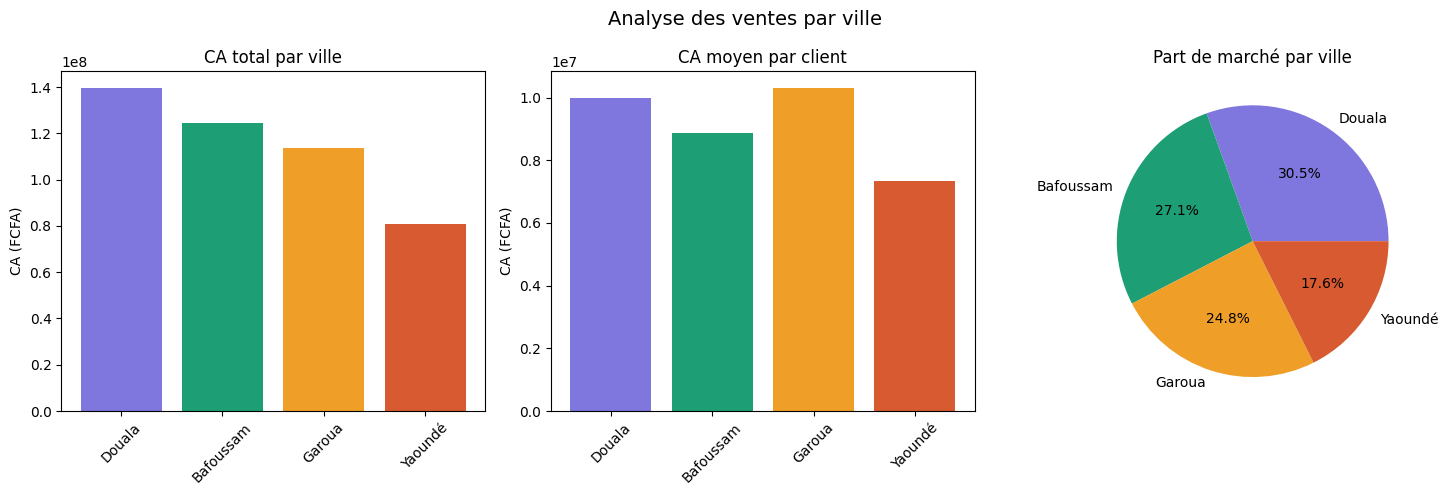

In [10]:
# La vraie puissance : combiner SQL et Pandas !

# 1. Requête SQL → DataFrame Pandas → Visualisation
print("=== CA PAR VILLE ===")
df_ca_ville = sql("""
    SELECT 
        c.ville,
        COUNT(DISTINCT c.client_id) as nb_clients,
        COUNT(co.commande_id) as nb_commandes,
        SUM(dc.quantite * dc.prix_unitaire) as ca_total,
        AVG(dc.quantite * dc.prix_unitaire) as ca_moyen
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
    GROUP BY c.ville
    ORDER BY ca_total DESC
""")
display(df_ca_ville)

# 2. Manipuler le résultat avec Pandas
df_ca_ville["ca_par_client"] = (df_ca_ville["ca_total"] / 
                                 df_ca_ville["nb_clients"]).round(0)
df_ca_ville["part_marche"] = (df_ca_ville["ca_total"] / 
                               df_ca_ville["ca_total"].sum() * 100).round(1)
print("\n=== APRÈS ENRICHISSEMENT PANDAS ===")
display(df_ca_ville)

# 3. Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CA total par ville
axes[0].bar(df_ca_ville["ville"], df_ca_ville["ca_total"], 
            color=["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30"])
axes[0].set_title("CA total par ville")
axes[0].set_ylabel("CA (FCFA)")
axes[0].tick_params(axis='x', rotation=45)

# CA par client
axes[1].bar(df_ca_ville["ville"], df_ca_ville["ca_par_client"],
            color=["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30"])
axes[1].set_title("CA moyen par client")
axes[1].set_ylabel("CA (FCFA)")
axes[1].tick_params(axis='x', rotation=45)

# Part de marché
axes[2].pie(df_ca_ville["part_marche"], 
            labels=df_ca_ville["ville"],
            autopct="%1.1f%%",
            colors=["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30"])
axes[2].set_title("Part de marché par ville")

plt.suptitle("Analyse des ventes par ville", fontsize=14)
plt.tight_layout()
plt.show()

<h4>💡 SQL + Pandas = combinaison parfaite !</h4>
<ul>
<li>SQL → extraire et agréger les données depuis la base</li>
<li>Pandas → enrichir, transformer et visualiser</li>
</ul>
En entreprise c'est exactement ce workflow qu'on utilise — SQL pour interroger la base de données, Pandas pour l'analyse ! 😄

<h3><b>Exercice pratique !</b></h3>

In [11]:
np.random.seed(42)
print("✅ Base de données créée !")

# Créer les tables
cursor.executescript("""
    DROP TABLE IF EXISTS clients;
    DROP TABLE IF EXISTS produits;
    DROP TABLE IF EXISTS commandes;
    DROP TABLE IF EXISTS details_commandes;
    
    CREATE TABLE clients (
        client_id INTEGER PRIMARY KEY,
        nom TEXT,
        ville TEXT,
        age INTEGER,
        segment TEXT
    );
    
    CREATE TABLE produits (
        produit_id INTEGER PRIMARY KEY,
        nom TEXT,
        categorie TEXT,
        prix REAL,
        stock INTEGER
    );
    
    CREATE TABLE commandes (
        commande_id INTEGER PRIMARY KEY,
        client_id INTEGER,
        date_commande TEXT,
        statut TEXT,
        FOREIGN KEY (client_id) REFERENCES clients(client_id)
    );
    
    CREATE TABLE details_commandes (
        detail_id INTEGER PRIMARY KEY,
        commande_id INTEGER,
        produit_id INTEGER,
        quantite INTEGER,
        prix_unitaire REAL,
        FOREIGN KEY (commande_id) REFERENCES commandes(commande_id),
        FOREIGN KEY (produit_id) REFERENCES produits(produit_id)
    );
""")

conn.commit()
print("✅ Tables créées !")


# Insérer les clients
clients = [
    (i, f"Client_{i}", 
     np.random.choice(["Douala", "Yaoundé", "Bafoussam", "Garoua"]),
     np.random.randint(18, 65),
     np.random.choice(["Premium", "Standard", "VIP"]))
    for i in range(1, 51)
]
cursor.executemany(
    "INSERT INTO clients VALUES (?, ?, ?, ?, ?)", clients)

# Insérer les produits
produits = [
    (1, "Laptop Pro", "Informatique", 850000, 20),
    (2, "Téléphone X", "Mobile", 250000, 50),
    (3, "Tablette Y", "Mobile", 180000, 30),
    (4, "Imprimante Z", "Informatique", 120000, 15),
    (5, "Casque Audio", "Accessoire", 45000, 100),
    (6, "Souris Sans Fil", "Accessoire", 15000, 200),
    (7, "Clavier", "Accessoire", 25000, 150),
    (8, "Moniteur HD", "Informatique", 320000, 25),
    (9, "Disque Dur", "Informatique", 75000, 40),
    (10, "Webcam", "Accessoire", 35000, 80)
]
cursor.executemany(
    "INSERT INTO produits VALUES (?, ?, ?, ?, ?)", produits)

# Insérer les commandes
commandes = [
    (i, np.random.randint(1, 51),
     f"2025-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}",
     np.random.choice(["Livrée", "En cours", "Annulée"], p=[0.7, 0.2, 0.1]))
    for i in range(1, 201)
]
cursor.executemany(
    "INSERT INTO commandes VALUES (?, ?, ?, ?)", commandes)

# Insérer les détails
details = [
    (i, np.random.randint(1, 201),
     np.random.randint(1, 11),
     np.random.randint(1, 5),
     np.random.randint(10000, 900000))
    for i in range(1, 401)
]
cursor.executemany(
    "INSERT INTO details_commandes VALUES (?, ?, ?, ?, ?)", details)

conn.commit()
print("✅ Données insérées !")
print(f"  - {len(clients)} clients")
print(f"  - {len(produits)} produits")
print(f"  - {len(commandes)} commandes")
print(f"  - {len(details)} détails de commandes")

✅ Base de données créée !
✅ Tables créées !
✅ Données insérées !
  - 50 clients
  - 10 produits
  - 200 commandes
  - 400 détails de commandes


<h4>Contexte : </h4>Tu es data scientist dans une banque camerounaise. Utilise la base de données qu'on a créée pour répondre aux questions business suivantes.
<h4>Ton travail :</h4>
<ol>
<li><b>Requête simple :</b> Liste tous les produits de la catégorie "Informatique" triés par prix décroissant</li>
<li><b>Agrégation : </b>Calcule le CA total, le nombre de ventes et le prix moyen par catégorie de produit</li>
<li><b>Jointure : </b>Trouve les 10 meilleurs clients avec leur ville, segment, nombre de commandes et CA total</li>
<li><b>HAVING :</b> Trouve les produits qui ont été vendus plus de 40 fois</li>
<li><b>CASE WHEN : </b>Classifie les produits en "Cher" (prix > 200 000), "Moyen" (entre 50 000 et 200 000) et "Abordable" (moins de 50 000)</li>
<li><b>Window Function :</b> Classe les clients par CA total avec RANK() et affiche leur rang</li>
<li><b>SQL + Pandas :</b> Récupère le CA par segment de client, enrichis avec Pandas et trace un graphique</li> </ol>

==Liste tous les produits de la catégorie informatique triés par ordre décroissant==


,produit_id,nom,categorie,prix,stock
0,1,Laptop Pro,Informatique,850000.0,20
1,8,Moniteur HD,Informatique,320000.0,25
2,4,Imprimante Z,Informatique,120000.0,15
3,9,Disque Dur,Informatique,75000.0,40


==Calcule le CA total, le nombre de ventes et le prix moyen par catégorie de produit==


,categorie,nb_ventes,ca_total,ca_moyen
0,Informatique,167,191383139.0,1.146007e+06
1,Accessoire,147,172893051.0,1.176143e+06
2,Mobile,86,94185382.0,1.095179e+06


==10 meilleurs clients avec leur ville, segment, nombre de commandes et CA total==


...

,nom,prix,segment_produits
0,Laptop Pro,850000.0,Cher
1,Moniteur HD,320000.0,Cher
2,Téléphone X,250000.0,Cher
3,Tablette Y,180000.0,Moyen
4,Imprimante Z,120000.0,Moyen
5,Disque Dur,75000.0,Moyen
6,Casque Audio,45000.0,Abordable
7,Webcam,35000.0,Abordable
8,Clavier,25000.0,Abordable
9,Souris Sans Fil,15000.0,Abordable


==Classe les clients par CA total avec RANK() et affiche leur rang==


,client,ville,ca_total,rang,rang_ville
0,Client_28,Garoua,24318607.0,1,1
1,Client_34,Douala,22552682.0,2,1
2,Client_3,Douala,19921846.0,3,2
3,Client_38,Garoua,19089415.0,4,2
4,Client_33,Bafoussam,18601063.0,5,1
5,Client_49,Yaoundé,18328113.0,6,1
6,Client_8,Yaoundé,16795299.0,7,2
7,Client_9,Douala,16245847.0,8,3
8,Client_1,Bafoussam,15616654.0,9,2
9,Client_48,Bafoussam,15426494.0,10,3


=== CA PAR SEGMENT DE CLIENT ===


,segment,ca_total,nb_clients,nb_commandes,ca_par_client,part_marche
0,Standard,174791936.0,20,165,8739597.0,38.1
1,VIP,157678522.0,17,138,9275207.0,34.4
2,Premium,125991114.0,13,97,9691624.0,27.5


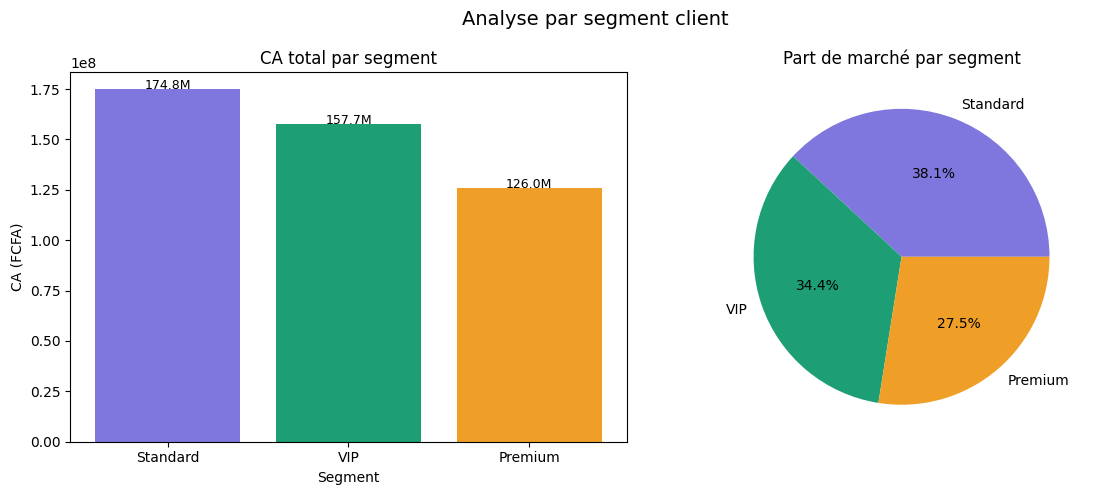


[OK] Connexion fermée proprement !


In [48]:
#1-Requête simple : Liste tous les produits de la catégorie "Informatique" triés par prix décroissant
print("==Liste tous les produits de la catégorie informatique triés par ordre décroissant==")
display(sql("""
    SELECT *
    FROM produits
    WHERE categorie='Informatique'
    ORDER BY prix DESC
"""))

#2-Agrégation : Calcule le CA total, le nombre de ventes et le prix moyen par catégorie de produit
print("==Calcule le CA total, le nombre de ventes et le prix moyen par catégorie de produit==")
display(sql("""
    SELECT 
        p.categorie,
        COUNT(*) as nb_ventes,
        SUM(dc.quantite * dc.prix_unitaire) as ca_total,
        AVG(dc.quantite * dc.prix_unitaire) as ca_moyen
    FROM details_commandes dc
    INNER JOIN produits p ON dc.produit_id = p.produit_id
    GROUP BY p.categorie
    ORDER BY ca_total DESC
"""))

#3-Jointure : Trouve les 10 meilleurs clients avec leur ville, segment, nombre de commandes et CA total
print("==10 meilleurs clients avec leur ville, segment, nombre de commandes et CA total==")
display(sql("""
    SELECT 
        c.nom,
        c.ville,
        c.segment,
        COUNT(co.commande_id) as nb_commandes,
        SUM(dc.quantite * dc.prix_unitaire) as ca_total
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
    GROUP BY c.client_id, c.nom, c.ville, c.segment
    ORDER BY ca_total DESC
    LIMIT 10
"""))

#4-HAVING : Trouve les produits qui ont été vendus plus de 40 fois
print("==Les produits qui ont été vendus plus de 40 fois==")
display(sql("""
    SELECT 
        p.nom,
        COUNT(*) as nb_ventes
    FROM produits p
    INNER JOIN details_commandes dc ON p.produit_id = dc.produit_id
    GROUP BY p.nom
    HAVING COUNT(*) > 40
    ORDER BY nb_ventes DESC
"""))

#5-CASE WHEN : Classifie les produits en "Cher", "Moyen" et "Abordable"
print("===Classifie les produits en 'Cher', 'Moyen' et 'Abordable'===")
display(sql("""
    SELECT 
        nom,
        prix,
        CASE 
            WHEN prix > 200000 THEN 'Cher'
            WHEN prix >= 50000 AND prix <= 200000 THEN 'Moyen'
            ELSE 'Abordable'
        END as segment_produits
    FROM produits
    ORDER BY prix DESC
"""))

#6-Window Function : Classe les clients par CA total avec RANK()
print("==Classe les clients par CA total avec RANK() et affiche leur rang==")
display(sql("""
    WITH ca_clients AS (
        SELECT 
            c.nom as client,
            c.ville as ville,
            SUM(dc.quantite * dc.prix_unitaire) as ca_total
        FROM clients c  
        INNER JOIN commandes co ON c.client_id = co.client_id
        INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
        GROUP BY c.client_id, c.nom, c.ville
    )
    SELECT 
        client,
        ville,
        ca_total,
        RANK() OVER (ORDER BY ca_total DESC) as rang,
        RANK() OVER (PARTITION BY ville ORDER BY ca_total DESC) as rang_ville
    FROM ca_clients
    ORDER BY rang
"""))

#7-SQL + Pandas : Récupère le CA par segment de client, enrichis avec Pandas et trace un graphique
print("=== CA PAR SEGMENT DE CLIENT ===")
df_ca_segment = sql("""
    SELECT 
        c.segment,       
        SUM(dc.quantite * dc.prix_unitaire) as ca_total,
        COUNT(DISTINCT c.client_id) as nb_clients,
        COUNT(co.commande_id) as nb_commandes
    FROM clients c
    INNER JOIN commandes co ON c.client_id = co.client_id
    INNER JOIN details_commandes dc ON co.commande_id = dc.commande_id
    GROUP BY c.segment
    ORDER BY ca_total DESC
""")

# Enrichissement Pandas
df_ca_segment["ca_par_client"] = (df_ca_segment["ca_total"] / 
                                   df_ca_segment["nb_clients"]).round(0)
df_ca_segment["part_marche"] = (df_ca_segment["ca_total"] / 
                                 df_ca_segment["ca_total"].sum() * 100).round(1)
display(df_ca_segment)

# Dashboard
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot CA total par segment
axes[0].bar(df_ca_segment["segment"], df_ca_segment["ca_total"],
            color=["#7F77DD", "#1D9E75", "#EF9F27"])
for i, v in enumerate(df_ca_segment["ca_total"]):
    axes[0].text(i, v + 100000, f"{v/1e6:.1f}M", ha="center", fontsize=9)
axes[0].set_title("CA total par segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("CA (FCFA)")

# Pie chart part de marché
axes[1].pie(df_ca_segment["part_marche"],
            labels=df_ca_segment["segment"],
            autopct="%1.1f%%",
            colors=["#7F77DD", "#1D9E75", "#EF9F27"])
axes[1].set_title("Part de marché par segment")

plt.suptitle("Analyse par segment client", fontsize=14)
plt.tight_layout()
plt.show()

# Fermer la connexion proprement
conn.close()
print("\n[OK] Connexion fermée proprement !")

### ✅ Bilan du Jour 9

Tu as maîtrisé aujourd'hui :

* [x] **Création d'une base de données SQLite**
* [x] **SELECT, WHERE, ORDER BY, LIMIT**
* [x] **Filtres avancés** : IN, BETWEEN, LIKE, IS NULL
* [x] **Jointures** : INNER JOIN, LEFT JOIN sur 4 tables
* [x] **Agrégations** : COUNT, SUM, AVG, MIN, MAX
* [x] **GROUP BY et HAVING**
* [x] **Sous-requêtes et CTE**
* [x] **CASE WHEN**
* [x] **Window Functions** : ROW_NUMBER, RANK
* [x] **Intégration SQL + Pandas + Visualisation**
* [x] **Exercice pratique complété 💪**